1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

#Load data
movies = pd.read_csv('../data/movies.csv')
ratings = pd.read_csv('../data/ratings.csv')

#merge
df = ratings.merge(movies, on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


2. Basic checks

In [2]:
print(movies.shape)
print(ratings.shape)

print(movies.isnull().sum())
print(ratings.isnull().sum())

(9742, 3)
(100836, 4)
movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


3. EDA: Key Insights

Most rated movies

In [3]:
df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64

Highest rated movies (with minimum votes filter)

In [4]:
movie_stats = df.groupby('title').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
)

movie_stats = movie_stats[movie_stats['num_ratings'] > 50]
movie_stats.sort_values('avg_rating', ascending=False).head(10)

,avg_rating,num_ratings
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


Ratings distribution

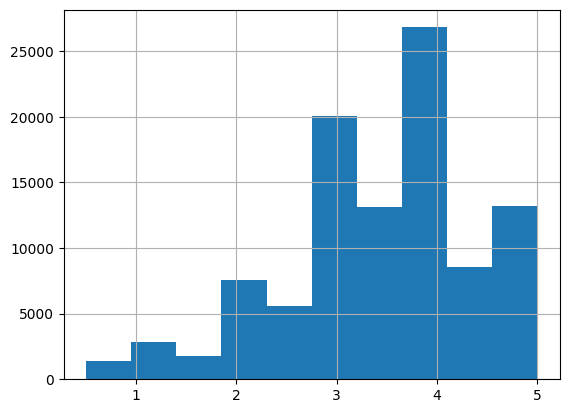

In [5]:
df['rating'].hist(bins=10)
plt.show()

4. Popularity-Based Recommender

In [6]:
def get_popular_movies(df, min_ratings=50, top_n=10):
    movie_stats = df.groupby('title').agg(
        avg_rating=('rating', 'mean'),
        num_ratings=('rating', 'count')
    )

    filtered = movie_stats[movie_stats['num_ratings'] >= min_ratings]

    return filtered.sort_values(
        by=['avg_rating', 'num_ratings'],
        ascending=False
    ).head(top_n)

get_popular_movies(df)

,avg_rating,num_ratings
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


5. Genre Processing

In [7]:
all_genres = set()

for g in movies['genres'].dropna():
    all_genres.update(g.split('|'))

all_genres = sorted(all_genres)

#removes useless
all_genres = [g for g in all_genres if g != '(no genres listed)']

print(all_genres)

['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


6. Genre-Based Recommender

In [8]:
def get_popular_by_genre(df, genre, min_ratings=50, top_n=10):

    genre_df = df[df['genres'].str.contains(
        rf'\b{genre}\b', case=False, na=False, regex=True
    )]

    movie_stats = genre_df.groupby('title').agg(
        avg_rating=('rating', 'mean'),
        num_ratings=('rating', 'count')
    )

    filtered = movie_stats[movie_stats['num_ratings'] >= min_ratings]

    return filtered.sort_values(
        by=['avg_rating', 'num_ratings'],
        ascending=False
    ).head(top_n)

get_popular_by_genre(df, 'Action')

,avg_rating,num_ratings
title,,
Fight Club (1999),4.272936,218
"Dark Knight, The (2008)",4.238255,149
"Princess Bride, The (1987)",4.232394,142
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Apocalypse Now (1979),4.219626,107
Star Wars: Episode V - The Empire Strikes Back (1980),4.215640,211
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),4.207500,200
"Matrix, The (1999)",4.192446,278
North by Northwest (1959),4.184211,57


Saving cleaned data

In [9]:
import os

# Create folder if not exists
os.makedirs('../data', exist_ok=True)

# Save cleaned data
df.to_csv('../data/cleaned_data.csv', index=False)